# 4. Train

Loads the already horizon-stacked training frame from notebook 3 and does the three things left: a **time-based split** (never shuffled, with an embargo gap so no training label leaks into the test window -- see `src/ml/dataset.py::time_split`), fitting one Random Forest model across all horizons, and evaluating it against EIA's own forecast on the exact same test rows.

The model **never sees EIA's forecast as an input feature** -- it's only used as the baseline. Otherwise "beats the EIA forecast" wouldn't mean much.

Every run is logged to MLflow (params, both sets of metrics, the model itself) so different runs can be compared instead of just reading numbers off this notebook's output.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import json
import os

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import pandas as pd
import yaml
from dotenv import load_dotenv

from src.ml.dataset import FEATURE_COLUMNS, time_split
from src.ml.model import evaluate, score, train_model

load_dotenv(PROJECT_ROOT / ".env")
train_params = yaml.safe_load(open(PROJECT_ROOT / "params.yaml"))["train"]
train_params

{'test_frac': 0.2,
 'embargo_hours': 24,
 'random_state': 42,
 'lightgbm': {'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 500},
 'xgboost': {'max_depth': 8, 'learning_rate': 0.05, 'n_estimators': 500},
 'catboost': {'depth': 8, 'learning_rate': 0.05, 'iterations': 500},
 'random_forest': {'n_estimators': 300, 'max_depth': 12}}

In [3]:
train_frame_path = PROJECT_ROOT / "data" / "processed" / "train_frame.csv"
stacked = pd.read_csv(train_frame_path, parse_dates=["demand_hour_utc"])

train_df, test_df = time_split(
    stacked,
    test_frac=train_params["test_frac"],
    embargo_hours=train_params["embargo_hours"],
)
print(
    f"train: {len(train_df):,} rows "
    f"({train_df['demand_hour_utc'].min()} -> {train_df['demand_hour_utc'].max()})"
)
print(
    f"test:  {len(test_df):,} rows "
    f"({test_df['demand_hour_utc'].min()} -> {test_df['demand_hour_utc'].max()})"
)

train: 2,503,423 rows (2021-07-12 17:00:00 -> 2025-07-06 01:00:00)
test:  622,332 rows (2025-07-07 01:00:00 -> 2026-07-04 15:00:00)


In [4]:
model_type = "random_forest"
model_params = {**train_params[model_type], "random_state": train_params["random_state"]}

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("gridcast-demand-forecast")

with mlflow.start_run(run_name=model_type) as run:
    mlflow.log_param("model_type", model_type)
    mlflow.log_params(model_params)
    mlflow.log_params(
        {
            "test_frac": train_params["test_frac"],
            "embargo_hours": train_params["embargo_hours"],
            "train_rows": len(train_df),
            "test_rows": len(test_df),
        }
    )

    model = train_model(train_df, model_type, model_params)
    test_scored, metrics = evaluate(model, test_df)

    mlflow.log_metrics({f"model_{k}": v for k, v in metrics["model"].items()})
    mlflow.log_metrics({f"baseline_{k}": v for k, v in metrics["baseline"].items()})

    by_horizon = []
    for horizon, group in test_scored.groupby("horizon"):
        h_model = score(group["target_mwh"], group["model_pred"])
        h_baseline = score(group["target_mwh"], group["baseline_mwh"])
        mlflow.log_metric("model_mae_by_horizon", h_model["mae"], step=horizon)
        mlflow.log_metric("baseline_mae_by_horizon", h_baseline["mae"], step=horizon)
        by_horizon.append(
            {"horizon": horizon, "model_mae": h_model["mae"], "baseline_mae": h_baseline["mae"]}
        )

    mlflow.sklearn.log_model(
        model, artifact_path="model", registered_model_name="gridcast-demand-forecaster-random-forest"
    )
    run_id = run.info.run_id

print(f"MLflow run: {run_id} ({model_type})")
print(f"model MAE={metrics['model']['mae']:.1f} MAPE={metrics['model']['mape']:.2%}")
print(f"baseline (EIA DF) MAE={metrics['baseline']['mae']:.1f} MAPE={metrics['baseline']['mape']:.2%}")

2026/07/17 21:40:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'gridcast-demand-forecaster-random-forest'.
2026/07/17 21:40:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: gridcast-demand-forecaster-random-forest, version 1


🏃 View run random_forest at: http://localhost:5000/#/experiments/1/runs/2624873ec51e4ea28c04cd700804f07c
🧪 View experiment at: http://localhost:5000/#/experiments/1
MLflow run: 2624873ec51e4ea28c04cd700804f07c (random_forest)
model MAE=4668.6 MAPE=8.01%
baseline (EIA DF) MAE=2315.5 MAPE=4.83%


Created version '1' of model 'gridcast-demand-forecaster-random-forest'.


### MAE by forecast horizon -- model vs. the EIA baseline

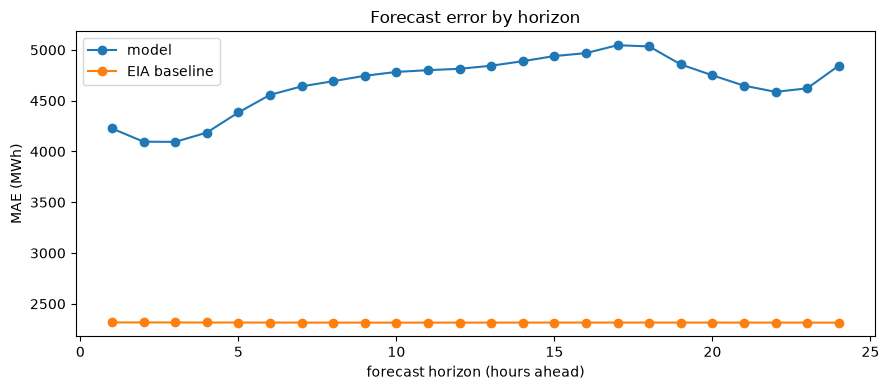

In [5]:
by_horizon_df = pd.DataFrame(by_horizon)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(by_horizon_df["horizon"], by_horizon_df["model_mae"], marker="o", label="model")
ax.plot(by_horizon_df["horizon"], by_horizon_df["baseline_mae"], marker="o", label="EIA baseline")
ax.set_xlabel("forecast horizon (hours ahead)")
ax.set_ylabel("MAE (MWh)")
ax.set_title("Forecast error by horizon")
ax.legend()
fig.tight_layout()
plt.show()

In [6]:
print(by_horizon_df.to_string(index=False))


 horizon   model_mae  baseline_mae
       1 4226.409347   2316.869632
       2 4096.365856   2316.664356
       3 4094.445265   2316.404368
       4 4185.855621   2316.144745
       5 4384.079488   2315.835395
       6 4557.041011   2315.493834
       7 4640.579501   2315.205303
       8 4692.186669   2315.024861
       9 4745.309581   2314.933811
      10 4783.323708   2314.920580
      11 4800.468172   2314.991787
      12 4814.274181   2315.086110
      13 4844.207499   2315.239732
      14 4888.959420   2315.396745
      15 4939.417159   2315.553254
      16 4968.475430   2315.635455
      17 5046.333121   2315.618744
      18 5034.122357   2315.501737
      19 4856.915385   2315.342712
      20 4749.819064   2315.230276
      21 4648.152788   2315.157228
      22 4586.954500   2315.076867
      23 4621.758777   2314.996023
      24 4844.707789   2314.849900


In [7]:
pd.Series(model.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)

demand_rolling_mean_24h     0.868067
demand_rolling_mean_168h    0.106974
horizon                     0.008287
hour_of_day                 0.005018
demand_lag_1h               0.002921
day_of_week                 0.002904
demand_rolling_std_24h      0.001922
demand_lag_24h              0.001704
demand_rolling_std_168h     0.001121
month                       0.000593
demand_lag_168h             0.000195
is_weekend                  0.000164
is_holiday                  0.000130
dtype: float64

In [8]:
model_path = PROJECT_ROOT / "models" / "model_random_forest.pkl"
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, model_path)

metrics_out = {
    "model_mae": metrics["model"]["mae"],
    "model_mape": metrics["model"]["mape"],
    "baseline_mae": metrics["baseline"]["mae"],
    "baseline_mape": metrics["baseline"]["mape"],
    "mlflow_run_id": run_id,
}
with open(PROJECT_ROOT / "metrics_random_forest.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

print(f"wrote {model_path}")
print(f"wrote {PROJECT_ROOT / 'metrics_random_forest.json'}")

wrote /Users/devashish/Desktop/Projects/gridcast/models/model_random_forest.pkl
wrote /Users/devashish/Desktop/Projects/gridcast/metrics_random_forest.json
